# Notebook 03 — Embeddings sémantiques multilingues

**Objectif** : Encoder les textes avec un modèle pré-entraîné (sentence-transformers multilingue), entraîner un classifieur sur ces embeddings, et comparer à la baseline TF-IDF du notebook 02.

## Approche

- **Modèle d'embeddings** : `paraphrase-multilingual-MiniLM-L12-v2` (384 dims, multilingue FR+DE+EN, optimisé pour la classification)
- **Classifieur** : Régression Logistique (config identique au notebook 02 pour comparaison équitable)
- **Workflow** : Encodage sur Google Colab (GPU T4 gratuit), classification en local
- **Splits** : Strictement identiques au notebook 02 (RANDOM_STATE=42)

## Hypothèse à tester

Les embeddings sémantiques devraient surtout aider sur :
- Les classes où le **vocabulaire est partagé** mais le **sens diffère** (livres, jouets)
- Les produits aux **descriptions courtes** où TF-IDF a peu de signal

Hypothèse opposée : sur les classes à vocabulaire ultra-spécifique (piscines, papeterie), peu de gain attendu — TF-IDF y est déjà excellent.

In [1]:
"""
Notebook 03 : Embeddings sémantiques multilingues
Étape 1 (locale) : préparation du fichier à uploader sur Colab.
"""

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Chargement du DataFrame nettoyé (notebook 01)
INPUT_PATH = Path("../data/processed/df_clean.parquet")
df = pd.read_parquet(INPUT_PATH)

print(f"Shape : {df.shape}")
print(f"Colonnes : {list(df.columns)}")

Shape : (84916, 6)
Colonnes : ['designation', 'description', 'text', 'text_clean', 'has_description', 'prdtypecode']


In [2]:
# IMPORTANT : on reconstruit les splits EXACTEMENT comme au notebook 02
# (même RANDOM_STATE, même séquence, même stratify)
X = df["text_clean"]
y = df["prdtypecode"]

# Étape 1 : trainval / test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)

# Étape 2 : train / val
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15/0.85, stratify=y_trainval, random_state=RANDOM_STATE
)

# Vérification : les tailles doivent être exactement les mêmes qu'au notebook 02
print(f"Train : {len(X_train):,}")
print(f"Val   : {len(X_val):,}")
print(f"Test  : {len(X_test):,}")
assert len(X_train) == 59440 and len(X_val) == 12738 and len(X_test) == 12738, "❌ Splits différents du notebook 02 !"
print("✅ Splits identiques au notebook 02")

Train : 59,440
Val   : 12,738
Test  : 12,738
✅ Splits identiques au notebook 02


In [3]:
# Création d'un DataFrame compact contenant tout ce dont Colab aura besoin
df_for_colab = df.copy()

# Tag du split de chaque ligne
df_for_colab["split"] = "none"
df_for_colab.loc[X_train.index, "split"] = "train"
df_for_colab.loc[X_val.index, "split"] = "val"
df_for_colab.loc[X_test.index, "split"] = "test"

# Vérification : aucune ligne ne doit rester en "none"
assert (df_for_colab["split"] == "none").sum() == 0, "❌ Lignes non assignées à un split"
print(f"Distribution des splits :")
print(df_for_colab["split"].value_counts())

# On garde uniquement ce dont Colab a besoin
COLAB_PATH = Path("../data/processed/for_colab.parquet")
df_for_colab[["text_clean", "prdtypecode", "split"]].to_parquet(COLAB_PATH, index=True)

print(f"\n✅ Fichier prêt pour Colab : {COLAB_PATH.resolve()}")
print(f"   Taille : {COLAB_PATH.stat().st_size / 1024**2:.2f} Mo")
print(f"   Shape : {df_for_colab.shape}")

Distribution des splits :
split
train    59440
test     12738
val      12738
Name: count, dtype: int64

✅ Fichier prêt pour Colab : C:\Users\kaism\OneDrive\Documents\Projet Perso\Adeo-marketplace-classification\Data\processed\for_colab.parquet
   Taille : 25.20 Mo
   Shape : (84916, 7)


## 2. Chargement des embeddings (depuis Drive)

Les embeddings ont été générés sur Google Colab avec GPU T4 (encodage en 3.4 min pour 85k textes).

On reconstruit ensuite les splits train/val/test en utilisant le tag `split` du fichier `for_colab.parquet`, qui garantit un alignement parfait avec les splits du notebook 02.

In [4]:
import json

# Chargement embeddings
EMB_PATH = Path("../data/processed/embeddings.npy")
META_PATH = Path("../data/processed/embeddings_metadata.json")

assert EMB_PATH.exists(), f"❌ Embeddings introuvables : {EMB_PATH.resolve()}"

embeddings = np.load(EMB_PATH)
with open(META_PATH) as f:
    emb_meta = json.load(f)

print("=== Embeddings ===")
print(f"Shape : {embeddings.shape}")
print(f"Dtype : {embeddings.dtype}")
print(f"Mémoire : {embeddings.nbytes / 1024**2:.1f} Mo")

print("\n=== Métadonnées ===")
print(json.dumps(emb_meta, indent=2))

=== Embeddings ===
Shape : (84916, 384)
Dtype : float32
Mémoire : 124.4 Mo

=== Métadonnées ===
{
  "model_name": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
  "embedding_dim": 384,
  "n_texts": 84916,
  "max_seq_length": 256,
  "batch_size": 64,
  "normalize_embeddings": true,
  "encoding_time_minutes": 3.36,
  "gpu": "Tesla T4"
}


In [5]:
# Rechargement du fichier qui contient les tags de split
df_colab = pd.read_parquet(Path("../data/processed/for_colab.parquet"))

# Vérification alignement : l'ordre des embeddings doit correspondre à l'ordre de df_colab
assert len(embeddings) == len(df_colab), "❌ Tailles incohérentes embeddings vs DataFrame"

# Mapping des indices par split (positions dans df_colab et donc dans embeddings)
train_mask = (df_colab["split"] == "train").values
val_mask   = (df_colab["split"] == "val").values
test_mask  = (df_colab["split"] == "test").values

# Extraction des embeddings et labels par split
X_train_emb = embeddings[train_mask]
X_val_emb   = embeddings[val_mask]
X_test_emb  = embeddings[test_mask]

y_train = df_colab.loc[train_mask, "prdtypecode"].values
y_val   = df_colab.loc[val_mask, "prdtypecode"].values
y_test  = df_colab.loc[test_mask, "prdtypecode"].values

print(f"Train : {X_train_emb.shape}  ({len(y_train):,} labels)")
print(f"Val   : {X_val_emb.shape}  ({len(y_val):,} labels)")
print(f"Test  : {X_test_emb.shape}  ({len(y_test):,} labels)")

# Vérification finale : tailles identiques au notebook 02
assert len(y_train) == 59440 and len(y_val) == 12738 and len(y_test) == 12738
print("\n✅ Splits alignés avec le notebook 02 (RANDOM_STATE=42)")

Train : (59440, 384)  (59,440 labels)
Val   : (12738, 384)  (12,738 labels)
Test  : (12738, 384)  (12,738 labels)

✅ Splits alignés avec le notebook 02 (RANDOM_STATE=42)


## 3. Entraînement du classifieur sur embeddings

On utilise **la même configuration LogReg que le notebook 02** pour garantir une comparaison équitable : seules les features changent (embeddings vs TF-IDF).

| Élément | Notebook 02 (baseline) | Notebook 03 (embeddings) |
|---------|------------------------|--------------------------|
| Features | TF-IDF, 50 000 dims sparses | Embeddings denses, 384 dims |
| Modèle | LogReg liblinear, balanced | LogReg liblinear, balanced |
| Splits | RANDOM_STATE=42 | Identiques |

L'écart de performance sera donc **entièrement attribuable** aux features.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from time import time
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid", context="notebook")

# Reproductibilité (déjà fait au début, on rappelle)
RANDOM_STATE = 42

In [8]:
# Configuration identique au notebook 02
model_emb = LogisticRegression(
    solver="liblinear",
    class_weight="balanced",
    C=1.0,
    max_iter=300,
    random_state=RANDOM_STATE,
)

print("Entraînement LogReg sur embeddings (384 dims denses)...")
t0 = time()
model_emb.fit(X_train_emb, y_train)
train_time_emb = time() - t0
print(f"✅ Entraînement terminé en {train_time_emb:.1f}s")
print(f"   Itérations max effectuées : {model_emb.n_iter_.max()}")

Entraînement LogReg sur embeddings (384 dims denses)...
✅ Entraînement terminé en 140.8s
   Itérations max effectuées : 12


## 4. Évaluation et comparaison à la baseline

On évalue le modèle embeddings sur les mêmes splits que la baseline (val + test), puis on compare directement chiffre à chiffre.

In [9]:
# Prédictions
print("Prédictions...")
t0 = time()
y_train_pred_emb = model_emb.predict(X_train_emb)
y_val_pred_emb   = model_emb.predict(X_val_emb)
y_test_pred_emb  = model_emb.predict(X_test_emb)
print(f"  → {time() - t0:.1f}s")

# Métriques embeddings
metrics_emb = pd.DataFrame({
    "Accuracy": [
        accuracy_score(y_train, y_train_pred_emb),
        accuracy_score(y_val,   y_val_pred_emb),
        accuracy_score(y_test,  y_test_pred_emb),
    ],
    "F1-macro": [
        f1_score(y_train, y_train_pred_emb, average="macro"),
        f1_score(y_val,   y_val_pred_emb,   average="macro"),
        f1_score(y_test,  y_test_pred_emb,  average="macro"),
    ],
    "F1-weighted": [
        f1_score(y_train, y_train_pred_emb, average="weighted"),
        f1_score(y_val,   y_val_pred_emb,   average="weighted"),
        f1_score(y_test,  y_test_pred_emb,  average="weighted"),
    ],
}, index=["Train", "Validation", "Test"]).round(4)

print("\n" + "=" * 70)
print("RÉSULTATS MODÈLE EMBEDDINGS")
print("=" * 70)
display(metrics_emb)

Prédictions...
  → 0.2s

RÉSULTATS MODÈLE EMBEDDINGS


,Accuracy,F1-macro,F1-weighted
Train,0.6796,0.6462,0.6776
Validation,0.6707,0.6377,0.6681
Test,0.6699,0.6344,0.6664


In [10]:
# Chargement des métriques baseline (sauvegardées au notebook 02)
with open(Path("../models/baseline_metrics.json")) as f:
    baseline_meta = json.load(f)

metrics_baseline = pd.DataFrame({
    "Accuracy":    [baseline_meta["metrics"][s]["Accuracy"]    for s in ["train", "validation", "test"]],
    "F1-macro":    [baseline_meta["metrics"][s]["F1-macro"]    for s in ["train", "validation", "test"]],
    "F1-weighted": [baseline_meta["metrics"][s]["F1-weighted"] for s in ["train", "validation", "test"]],
}, index=["Train", "Validation", "Test"]).round(4)

# Tableau de comparaison
comparison = pd.DataFrame({
    "Baseline (TF-IDF)":   metrics_baseline["F1-macro"],
    "Embeddings (MiniLM)": metrics_emb["F1-macro"],
})
comparison["Delta (pts)"] = ((comparison["Embeddings (MiniLM)"] - comparison["Baseline (TF-IDF)"]) * 100).round(2)

print("=" * 70)
print("COMPARAISON F1-MACRO : BASELINE vs EMBEDDINGS")
print("=" * 70)
display(comparison)

# Comparaison globale (accuracy + f1)
print("\nVue d'ensemble (Test set uniquement) :")
test_compare = pd.DataFrame({
    "Baseline TF-IDF":   metrics_baseline.loc["Test"],
    "Embeddings MiniLM": metrics_emb.loc["Test"],
})
test_compare["Delta (pts)"] = ((test_compare["Embeddings MiniLM"] - test_compare["Baseline TF-IDF"]) * 100).round(2)
display(test_compare)

COMPARAISON F1-MACRO : BASELINE vs EMBEDDINGS


,Baseline (TF-IDF),Embeddings (MiniLM),Delta (pts)
Train,0.8706,0.6462,-22.44
Validation,0.7975,0.6377,-15.98
Test,0.7959,0.6344,-16.15



Vue d'ensemble (Test set uniquement) :


,Baseline TF-IDF,Embeddings MiniLM,Delta (pts)
Accuracy,0.8064,0.6699,-13.65
F1-macro,0.7959,0.6344,-16.15
F1-weighted,0.8066,0.6664,-14.02


## 5. Analyse comparative par classe

Le F1-macro global montre un écart de -16 points. Mais l'écart est-il **uniforme** sur toutes les classes, ou les embeddings perdent-ils surtout sur certaines catégories spécifiques ?

Cette section croise les F1-scores par classe pour identifier où les deux approches divergent.

In [27]:
# Réalignement des prédictions baseline avec l'ordre actuel des splits
# (les indices doivent être en int Python natif pour matcher le dict de lookup)
val_indices_baseline = [int(i) for i in baseline_preds["val_indices"]]
y_val_pred_raw = np.array(baseline_preds["y_val_pred"])
pred_lookup_val = dict(zip(val_indices_baseline, y_val_pred_raw))

val_df_indices = [int(i) for i in df_colab.loc[df_colab["split"] == "val"].index.tolist()]
y_val_pred_baseline = np.array([pred_lookup_val[i] for i in val_df_indices])

test_indices_baseline = [int(i) for i in baseline_preds["test_indices"]]
y_test_pred_raw = np.array(baseline_preds["y_test_pred"])
pred_lookup_test = dict(zip(test_indices_baseline, y_test_pred_raw))
test_df_indices = [int(i) for i in df_colab.loc[df_colab["split"] == "test"].index.tolist()]
y_test_pred_baseline = np.array([pred_lookup_test[i] for i in test_df_indices])

# Vérification du réalignement
f1_check = f1_score(y_val, y_val_pred_baseline, average="macro")
assert abs(f1_check - 0.7975) < 0.005, f"❌ Alignement incorrect, F1={f1_check}"
print(f"✅ Réalignement validé (F1-macro baseline val = {f1_check:.4f})")

✅ Réalignement validé (F1-macro baseline val = 0.7975)


In [29]:
# Classification report par classe pour les deux modèles
report_baseline = classification_report(y_val, y_val_pred_baseline, output_dict=True, zero_division=0)
report_emb     = classification_report(y_val, y_val_pred_emb,      output_dict=True, zero_division=0)

# Tableau comparatif
classes_sorted = sorted(df_colab["prdtypecode"].unique())
class_compare = pd.DataFrame({
    "f1_baseline":   [report_baseline[str(c)]["f1-score"] for c in classes_sorted],
    "f1_embeddings": [report_emb[str(c)]["f1-score"]      for c in classes_sorted],
    "n_val":         [report_baseline[str(c)]["support"]  for c in classes_sorted],
}, index=classes_sorted).round(3)
class_compare["delta"] = (class_compare["f1_embeddings"] - class_compare["f1_baseline"]).round(3)
class_compare.index.name = "prdtypecode"

# Tri par delta (du pire au meilleur pour embeddings)
class_compare_sorted = class_compare.sort_values("delta", ascending=True)

print("Comparaison F1 par classe (triées par delta croissant) :")
display(class_compare_sorted)

# Synthèse
n_emb_wins = (class_compare["delta"] > 0).sum()
n_emb_loses = (class_compare["delta"] < 0).sum()
n_emb_equal = (class_compare["delta"] == 0).sum()
print(f"\nNombre de classes où embeddings > baseline : {n_emb_wins}")
print(f"Nombre de classes où embeddings < baseline : {n_emb_loses}")
print(f"Nombre de classes où embeddings = baseline : {n_emb_equal}")

Comparaison F1 par classe (triées par delta croissant) :


,f1_baseline,f1_embeddings,n_val,delta
prdtypecode,,,,
1301,0.938,0.632,121.0,-0.306
2585,0.785,0.490,374.0,-0.295
1180,0.667,0.386,115.0,-0.281
1320,0.787,0.522,486.0,-0.265
1940,0.873,0.657,121.0,-0.216
50,0.820,0.607,252.0,-0.213
1302,0.763,0.551,374.0,-0.212
1281,0.619,0.409,310.0,-0.210
2220,0.876,0.684,124.0,-0.192



Nombre de classes où embeddings > baseline : 0
Nombre de classes où embeddings < baseline : 27
Nombre de classes où embeddings = baseline : 0


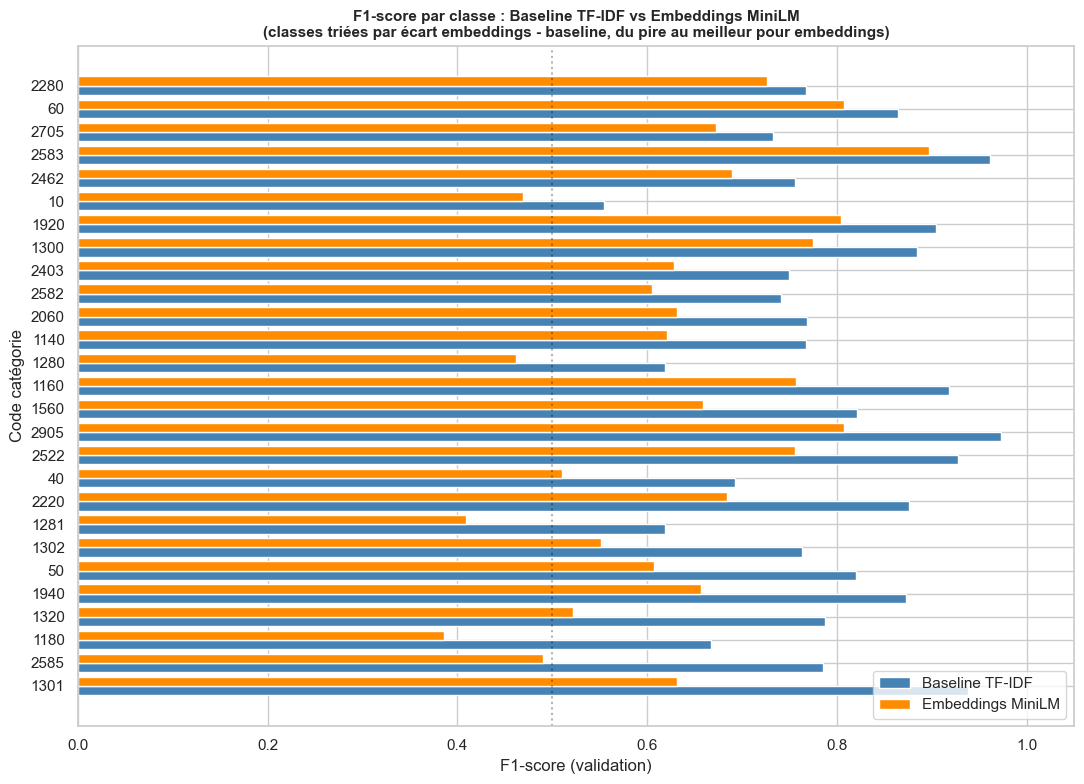

In [30]:
fig, ax = plt.subplots(figsize=(11, 8))

plot_data = class_compare_sorted.reset_index()
plot_data["prdtypecode"] = plot_data["prdtypecode"].astype(str)

x = np.arange(len(plot_data))
width = 0.4

ax.barh(x - width/2, plot_data["f1_baseline"],   width, label="Baseline TF-IDF",  color="steelblue")
ax.barh(x + width/2, plot_data["f1_embeddings"], width, label="Embeddings MiniLM", color="darkorange")

ax.set_yticks(x)
ax.set_yticklabels(plot_data["prdtypecode"])
ax.set_xlabel("F1-score (validation)")
ax.set_ylabel("Code catégorie")
ax.set_title(
    "F1-score par classe : Baseline TF-IDF vs Embeddings MiniLM\n"
    "(classes triées par écart embeddings - baseline, du pire au meilleur pour embeddings)",
    fontsize=11,
    fontweight="bold",
)
ax.axvline(0.5, color="black", linestyle=":", alpha=0.3)
ax.legend(loc="lower right")
ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.show()

## 6. Conclusion

L'hypothèse "embeddings sémantiques > TF-IDF" est infirmée sur ce dataset : F1-macro test **0.634** vs baseline **0.796** (-16 pts, perte uniforme sur 27/27 classes). Diagnostic complet et pistes V3 traités dans le README.

In [31]:
# Sauvegarde des prédictions embeddings (réutilisables pour le README/analyses futures)
predictions_emb = {
    "y_val_pred":   y_val_pred_emb.tolist(),
    "y_test_pred":  y_test_pred_emb.tolist(),
    "val_indices":  val_df_indices,
    "test_indices": test_df_indices,
}
with open(Path("../models/embeddings_predictions.json"), "w") as f:
    json.dump(predictions_emb, f)

# Sauvegarde des métriques embeddings
metrics_emb_dict = {
    "model": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2 + LogReg",
    "embedding_metadata": emb_meta,
    "random_state": RANDOM_STATE,
    "train_time_logreg_sec": round(train_time_emb, 1),
    "metrics": {
        "train":      metrics_emb.loc["Train"].to_dict(),
        "validation": metrics_emb.loc["Validation"].to_dict(),
        "test":       metrics_emb.loc["Test"].to_dict(),
    },
    "comparison_vs_baseline_test": {
        "baseline_f1_macro":   round(metrics_baseline.loc["Test", "F1-macro"], 4),
        "embeddings_f1_macro": round(metrics_emb.loc["Test", "F1-macro"], 4),
        "delta_pts":           round((metrics_emb.loc["Test", "F1-macro"] - metrics_baseline.loc["Test", "F1-macro"]) * 100, 2),
    },
    "n_classes_emb_wins": int((class_compare["delta"] > 0).sum()),
    "n_classes_emb_loses": int((class_compare["delta"] < 0).sum()),
}
with open(Path("../models/embeddings_metrics.json"), "w") as f:
    json.dump(metrics_emb_dict, f, indent=2, default=float)

# Sauvegarde du modèle LogReg sur embeddings
import joblib
joblib.dump(model_emb, Path("../models/logreg_embeddings.joblib"))

print("✅ Artefacts sauvegardés :")
for f in sorted(Path("../models").iterdir()):
    if f.is_file():
        size_mb = f.stat().st_size / 1024**2
        print(f"  {f.name:<40s} {size_mb:>6.2f} Mo")

✅ Artefacts sauvegardés :
  baseline_metrics.json                      0.00 Mo
  baseline_predictions.json                  0.31 Mo
  embeddings_metrics.json                    0.00 Mo
  embeddings_predictions.json                0.31 Mo
  logreg_baseline.joblib                    10.30 Mo
  logreg_embeddings.joblib                   0.08 Mo
  tfidf_vectorizer.joblib                    1.90 Mo
